In [7]:
# Imports
from transformers import BertModel, BertTokenizer, logging
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import torch
import random
import re

Loaded 264 pairs with score 0.8 <= score <= 1.0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Precomputed 50/264 activations
Precomputed 100/264 activations
Precomputed 150/264 activations
Precomputed 200/264 activations
Precomputed 250/264 activations
Analyzing Layer 0
Analyzing Layer 1
Analyzing Layer 2
Analyzing Layer 3
Analyzing Layer 4
Analyzing Layer 5
Analyzing Layer 6
Analyzing Layer 7
Analyzing Layer 8
Analyzing Layer 9
Analyzing Layer 10
Analyzing Layer 11


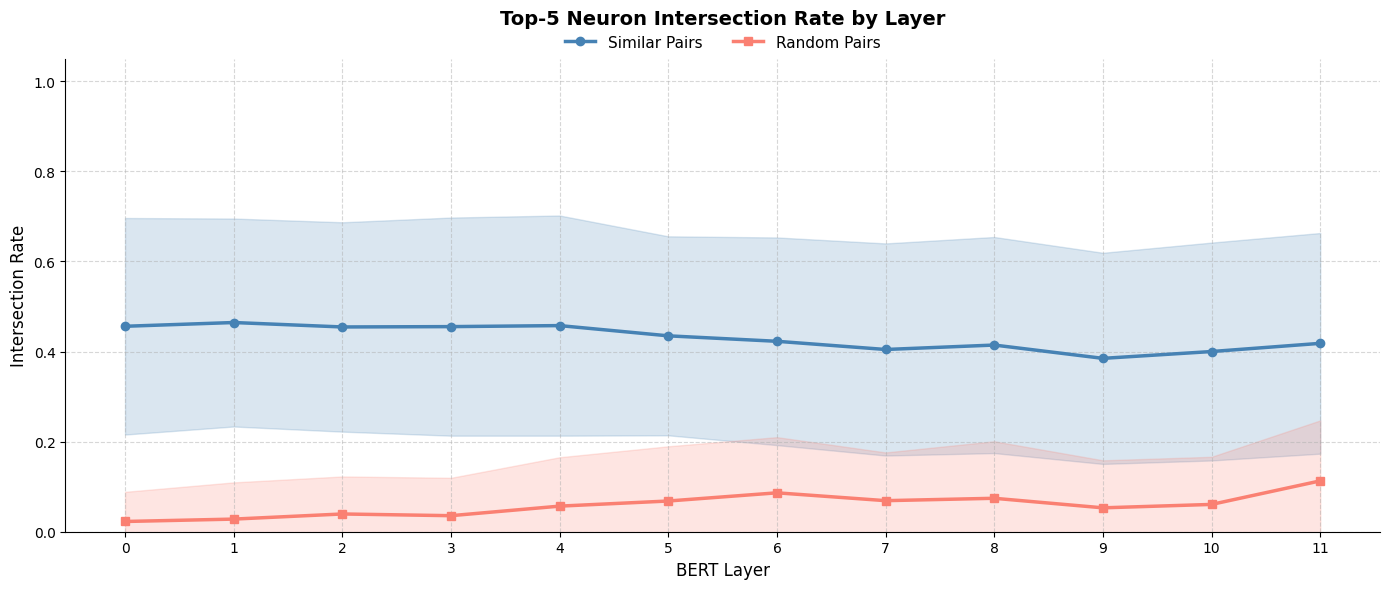

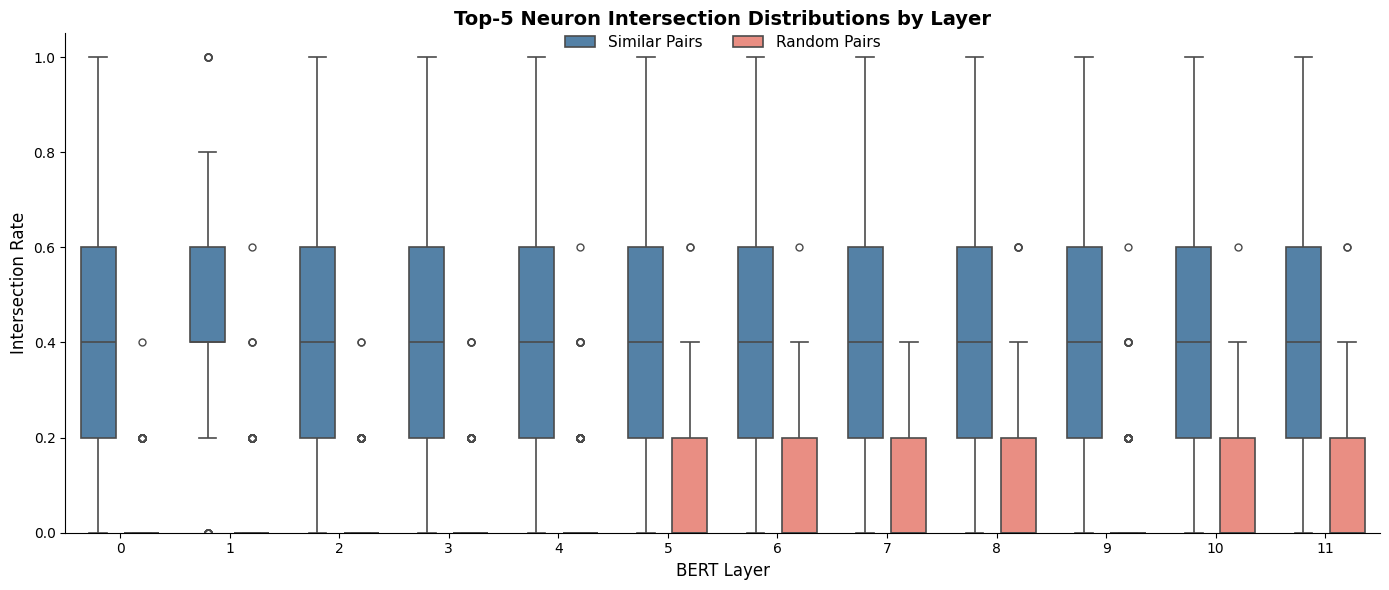

In [8]:
# Suppress warnings from unused pre-training heads
logging.set_verbosity_error()

# Load STS-B dataset and filter by score range
def load_stsb(min_score = 0.8, max_score = 1.0, split = "validation"):
    
    dataset = load_dataset("sentence-transformers/stsb")
    
    if min_score is not None and max_score is not None:
        dataset = dataset[split].filter(lambda x: min_score <= x["score"] <= max_score)
    else:
        dataset = dataset[split]
    
    print(f"Loaded {len(dataset)} pairs with score {min_score} <= score <= {max_score}")
    return dataset


# Load BERT model and tokenizer
def load_model(model_name = "bert-base-uncased"):
    
    tokenizer = BertTokenizer.from_pretrained(model_name)
    model = BertModel.from_pretrained(model_name, output_hidden_states = True)
    model.eval()
    
    return tokenizer, model


# Compute all layer activations for a sentence (cache activations to avoid recomputation)
def compute_activations(sentence, tokenizer, model):
    
    inputs = tokenizer(sentence, return_tensors = "pt", truncation = True, max_length = 128)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # hidden_states[0] is embeddings; hidden_states[1:] are the 12 layers
    # Exclude [CLS] and [SEP] tokens
    return [layer.squeeze(0)[1:-1].numpy() for layer in outputs.hidden_states[1:]]


# Extract top-k neurons from precomputed activations for a given layer
def get_top_k_from_activations(layer_activations, layer_index, k = 50):
    
    neuron_scores = layer_activations[layer_index].max(axis = 0)  # max across tokens
    top_k_indices = set(np.argsort(neuron_scores)[-k:])
    
    return top_k_indices


# Compute intersection rate between two sets of top-k neuron indices
def intersection_rate(set_a, set_b, k = 50):
    return len(set_a & set_b) / k


# Run analysis for a single layer using cached activations
def run_layer_analysis(dataset_activations, layer_index, k = 50):
    
    similar_intersections = []
    random_intersections = []

    # Extract top-k neuron sets for all pairs at this layer
    top_k_sets = []
    for act1, act2 in dataset_activations:
        set1 = get_top_k_from_activations(act1, layer_index, k)
        set2 = get_top_k_from_activations(act2, layer_index, k)
        top_k_sets.append((set1, set2))

    # Calculate intersection rates for true similar pairs
    for set1, set2 in top_k_sets:
        similar_intersections.append(intersection_rate(set1, set2, k))

    # Generate random baseline by shuffling sentence2
    indices = np.random.permutation(len(top_k_sets))
    for i, j in enumerate(indices):
        random_intersections.append(intersection_rate(top_k_sets[i][0], top_k_sets[j][1], k))

    return {
        "similar": similar_intersections,
        "random": random_intersections
    }


# Run analysis across all layers using cached activations
def run_analysis_all_layers(min_score = 0.8, max_score = 1.0, k = 50):
    
    # Load dataset
    dataset = load_stsb(min_score, max_score)
    
    # Load BERT model and tokenizer
    tokenizer, model = load_model()
    num_layers = model.config.num_hidden_layers

    # Precompute activations for all sentences in the dataset
    dataset_activations = []
    for i, example in enumerate(dataset):
        act1 = compute_activations(example["sentence1"], tokenizer, model)
        act2 = compute_activations(example["sentence2"], tokenizer, model)
        dataset_activations.append((act1, act2))

        if (i + 1) % 50 == 0:
            print(f"Precomputed {i+1}/{len(dataset)} activations")

    # Run analysis for each layer
    results_by_layer = {}
    for layer_index in range(num_layers):
        print(f"Analyzing Layer {layer_index}")
        layer_results = run_layer_analysis(dataset_activations, layer_index, k)
        results_by_layer[layer_index] = layer_results

        # print(f"  Similar mean: {np.mean(layer_results['similar']):.4f}, "
        # f"Random mean: {np.mean(layer_results['random']):.4f}")

    return results_by_layer


# Plot intersection rate trends across layers
def plot_by_layer(results_by_layer, k):
    
    layers = sorted(results_by_layer.keys())
    
    sim_means = [np.mean(results_by_layer[l]['similar']) for l in layers]
    sim_stds  = [np.std(results_by_layer[l]['similar']) for l in layers]
    ran_means = [np.mean(results_by_layer[l]['random']) for l in layers]
    ran_stds  = [np.std(results_by_layer[l]['random']) for l in layers]

    plt.figure(figsize = (14, 6))

    # Plot similar pairs
    plt.plot(layers, sim_means, marker = 'o', color = 'steelblue', label = 'Similar Pairs', linewidth = 2.5)
    plt.fill_between(layers, 
                     np.array(sim_means) - np.array(sim_stds), 
                     np.array(sim_means) + np.array(sim_stds), 
                     color = 'steelblue', alpha = 0.2)

    # Plot random pairs
    plt.plot(layers, ran_means, marker = 's', color = 'salmon', label = 'Random Pairs', linewidth = 2.5)
    plt.fill_between(layers, 
                     np.array(ran_means) - np.array(ran_stds), 
                     np.array(ran_means) + np.array(ran_stds), 
                     color = 'salmon', alpha = 0.2)

    # Formatting
    plt.title(f'Top-{k} Neuron Intersection Rate by Layer', fontsize = 14, pad = 25, fontweight = 'bold')
    plt.xlabel('BERT Layer', fontsize = 12)
    plt.ylabel('Intersection Rate', fontsize = 12)
    plt.xticks(layers)
    plt.ylim(0, 1.05)
    plt.grid(True, linestyle = '--', alpha = 0.5)
    
    # Legend horizontally below the title, no frame
    plt.legend(fontsize = 11, loc = 'upper center', ncol = 2, frameon = False, bbox_to_anchor = (0.5, 1.08))
    
    sns.despine(left = False, bottom = False)  # remove top and right spines
    plt.tight_layout()
    plt.savefig("bert_intersection_trend.png", dpi = 150)
    plt.show()


# Plot boxplots of intersection distributions
def plot_boxplot(results_by_layer, k):
    
    # Flatten data into a DataFrame
    data = []
    for layer, res in results_by_layer.items():
        for val in res['similar']:
            data.append({'Layer': layer, 'Intersection Rate': val, 'Pair Type': 'Similar Pairs'})
        for val in res['random']:
            data.append({'Layer': layer, 'Intersection Rate': val, 'Pair Type': 'Random Pairs'})

    df = pd.DataFrame(data)

    plt.figure(figsize = (14, 6))
    sns.boxplot(data = df, x = 'Layer', y = 'Intersection Rate', hue = 'Pair Type',
                palette = {'Similar Pairs': 'steelblue', 'Random Pairs': 'salmon'},
                fliersize = 5, linewidth = 1.2, gap = 0.2)

    plt.title(f'Top-{k} Neuron Intersection Distributions by Layer', fontsize = 14, fontweight = 'bold')
    plt.ylabel('Intersection Rate', fontsize = 12)
    plt.xlabel('BERT Layer', fontsize = 12)
    plt.ylim(0, 1.05)

    # Legend horizontally below the title, no frame
    plt.legend(fontsize = 11, loc = 'upper center', ncol = 2, frameon = False, bbox_to_anchor = (0.5, 1.025))

    sns.despine(left = False, bottom = False)
    plt.tight_layout()
    plt.savefig("bert_intersection_boxplot.png", dpi = 150)
    plt.show()


# Main execution
if __name__ == "__main__":
    # k = 5 for top-k neurons
    k = 5
    results = run_analysis_all_layers(min_score = 0.8, max_score = 1.0, k = k)
    plot_by_layer(results, k = k)
    plot_boxplot(results, k = k)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Top neurons determined for 'plane'
Top neurons determined for 'river'
Top neurons determined for 'candle'
Top neurons determined for 'guitar'
Top neurons determined for 'window'


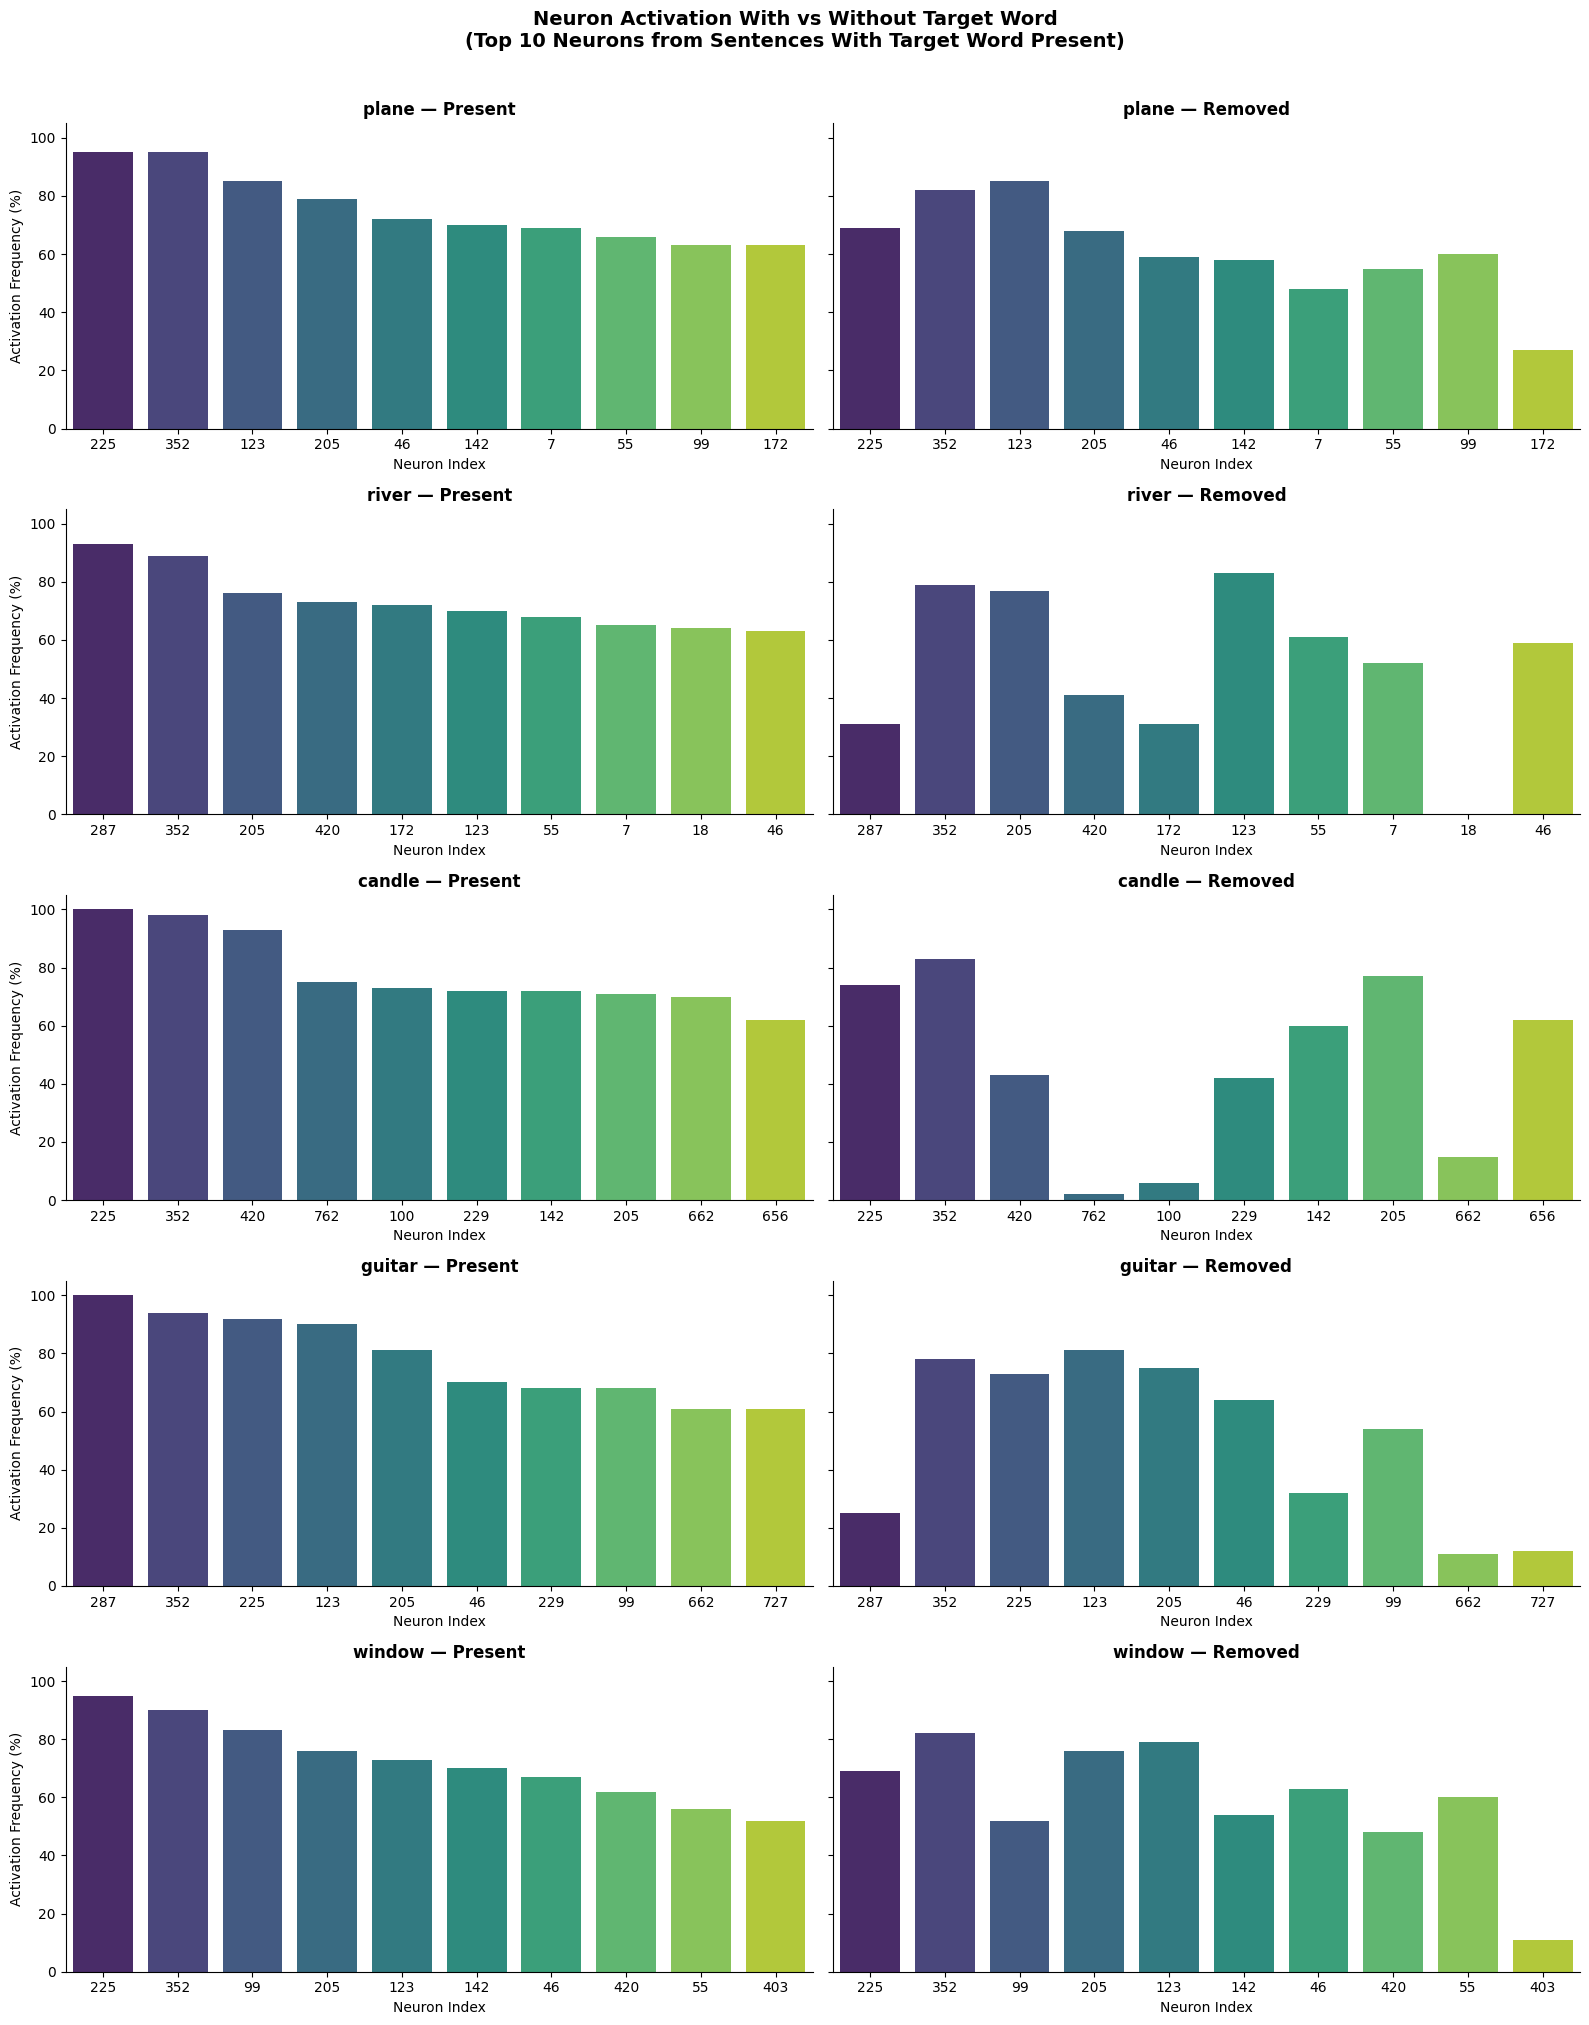

In [9]:
# Suppress warning from unused pre-training heads
logging.set_verbosity_error()


# Load the BERT model and tokenizer
def load_model(model_name = "bert-base-uncased"):
    tokenizer = BertTokenizer.from_pretrained(model_name)
    model = BertModel.from_pretrained(model_name, output_hidden_states = True)
    model.eval()
    return tokenizer, model


# Function to remove a specific word from a sentence (case-insensitive, whole word match)
def remove_word(sentence, word):
    pattern = r'\b{}\b'.format(re.escape(word))
    sentence = re.sub(pattern, '', sentence, flags = re.IGNORECASE)
    sentence = re.sub(r'\s+', ' ', sentence).strip()
    return sentence

# Function to create a modified DataFrame where the target word is removed from all sentences
def create_half_removed_df(df):

    # Copy dataframe
    df_mod = df.copy()

    # Loop through each row
    for idx, row in df_mod.iterrows():

        # Extract the target word and sentences
        word = str(row.iloc[0])
        sentences = row.iloc[1:].tolist()

        # Select sentence indices
        indices = list(range(len(sentences)))

        # Remove the target word from all sentences
        for i in indices:
            sentences[i] = remove_word(str(sentences[i]), word)

        # Update the DataFrame with modified sentences
        df_mod.iloc[idx, 1:] = sentences

    return df_mod


# Function to extract a single vector representation for a sentence by taking the max activation across tokens for each neuron
def extract_sentence_vector(sentence, tokenizer, model, layer_index = -1):

    # Get activations for the sentence
    inputs = tokenizer(sentence, return_tensors = "pt", truncation = True, max_length = 128)

    # Get hidden states for the specified layer
    with torch.no_grad():
        outputs = model(**inputs)
    hidden_state = outputs.hidden_states[layer_index].squeeze(0)

    # Exclude [CLS] and [SEP] tokens if present
    if hidden_state.shape[0] > 2:
        layer_acts = hidden_state[1:-1].numpy()
    else:
        layer_acts = hidden_state.numpy()

    # Take max activation across tokens for each neuron to get a single vector representation
    neuron_scores = layer_acts.max(axis = 0)

    return neuron_scores


# Function to determine the percentage of sentences that activate each neuron above the 95th percentile threshold, and return the top 10 neurons for each target word
def find_top_neurons(df, tokenizer, model):

    # Get number of neurons from model config
    num_neurons = model.config.hidden_size
    results = {}

    # Loop through each row in the DataFrame
    for idx, row in df.iterrows():

        # Get the target word and sentences
        word = str(row.iloc[0])
        sentences = row.iloc[1:].dropna().values

        # Array to hold counts of how many sentences activate each neuron above the threshold
        neuron_active_counts = np.zeros(num_neurons)

        # Loop through sentences
        for sent in sentences:
            
            # Extract neuron scores for the sentence
            neuron_scores = extract_sentence_vector(str(sent), tokenizer, model)

            # Convert to magnitudes and get the 95th percentile threshold
            magnitudes = np.abs(neuron_scores)
            threshold = np.percentile(magnitudes, 95)

            # Determine which neurons are active above the threshold
            is_active = (magnitudes >= threshold).astype(int)

            # Update counts for each neuron
            neuron_active_counts += is_active

        # Calculate the percentage of sentences that activate each neuron above the threshold
        percentages = neuron_active_counts / len(sentences) * 100

        # Get the top 10 neurons based on activation percentage
        top10 = np.argsort(percentages)[-10:][::-1]
        results[word] = top10

        print(f"Top neurons determined for '{word}'")

    return results


# Function to evaluate the activation of the identified neurons in both original and modified datasets, and return the percentage of sentences that activate each neuron above the threshold
def evaluate_neurons(df, tokenizer, model, neuron_map):

    # Dictionary to hold results for each word
    results = {}

    # Loop through each row in the DataFrame
    for idx, row in df.iterrows():

        # Get the target word, neurons to evaluate, and sentences
        word = str(row.iloc[0])
        neurons = neuron_map[word]
        sentences = row.iloc[1:].dropna().values

        # Array to hold counts of how many sentences activate each neuron above the threshold
        counts = np.zeros(len(neurons))

        # Loop through sentences
        for sent in sentences:

            # Extract neuron scores for the sentence
            neuron_scores = extract_sentence_vector(str(sent), tokenizer, model)

            # Convert to magnitudes and get the 95th percentile threshold
            magnitudes = np.abs(neuron_scores)
            threshold = np.percentile(magnitudes, 95)

            # Check if each of the identified neurons is active above the threshold and update counts
            for i, n in enumerate(neurons):
                if magnitudes[n] >= threshold:
                    counts[i] += 1

        # Calculate the percentage of sentences that activate each neuron above the threshold
        percentages = counts / len(sentences) * 100

        # Store results for the word
        results[word] = {
            "indices": neurons,
            "percentages": percentages
        }

    return results


# Function to plot the comparison of neuron activation between original and modified datasets
def plot_comparison(original_results, removed_results):

    # Get list of words from the results
    words = list(original_results.keys())

    # Initialize the figure and axes for subplots
    fig, axes = plt.subplots(len(words), 2, figsize = (16, 4*len(words)), sharey = True)

    # Loop through each target word
    for i, word in enumerate(words):

        # Loop through original and removed results for the word
        for j, (results, label) in enumerate([(original_results, "Present"), (removed_results, "Removed")]):

            # Get current axis for plotting
            ax = axes[i][j]

            # Get neuron indices and activation percentages for the current condition
            indices = results[word]["indices"]
            pcts = results[word]["percentages"]

            # Create x-axis labels based on neuron indices
            x_labels = [str(i) for i in indices]

            # Plot bar chart of activation percentages for the identified neurons
            sns.barplot(
                x = x_labels,
                y = pcts,
                ax = ax,
                palette = "viridis",
                hue = x_labels,
                legend = False
            )

            # Set y-axis limits and labels
            ax.set_ylim(0, 105)
            ax.set_xlabel("Neuron Index")

            if j == 0:
                ax.set_ylabel("Activation Frequency (%)")
            else:
                ax.set_ylabel("")

            # Set title for each subplot
            ax.set_title(f"{word} — {label}", fontweight = "bold")

            # Remove top and right spines for cleaner look
            sns.despine(ax = ax)

    # Add super title for the entire figure
    plt.suptitle(
        "Neuron Activation With vs Without Target Word\n(Top 10 Neurons from Sentences With Target Word Present)",
        fontsize = 14,
        fontweight = "bold",
        y = 1.01
    )

    # Show and save the plot
    plt.tight_layout()
    plt.savefig("neuron_word_removal_comparison.png", dpi = 150, bbox_inches = "tight")
    plt.show()


# Main execution
if __name__ == "__main__":

    # Load in the dataset containing sentences with common words
    df = pd.read_csv("common_word_sentences_dataset.csv")

    # Load the BERT model and tokenizer
    tokenizer, model = load_model()

    # Identify top neurons from original data
    top_neurons = find_top_neurons(df, tokenizer, model)

    # Create modified dataset
    df_removed = create_half_removed_df(df)

    # Measure activation in both conditions
    original_results = evaluate_neurons(df, tokenizer, model, top_neurons)
    removed_results = evaluate_neurons(df_removed, tokenizer, model, top_neurons)

    # Plot the comparison of neuron activation between original and modified datasets
    plot_comparison(original_results, removed_results)